<center><span style="font-size:50px;"><b>Abe-Suzuki Earthquake Network</b></span></center>

---

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
from pyproj import Transformer # this library deals with coordinates
import time
from collections import Counter


import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import linregress
import seaborn as sns

---

### TEST DEBUG

In [5]:
# Define your path sequence
path = ['B', 'A', 'B', 'D', 'B', 'A', 'C', 'A', 'A', 'D']
G = nx.DiGraph()   # Create a directed graph

# zip(path, path[1:]) creates pairs like ('A', 'B'), ('B', 'D'), etc.
for source, target in zip(path, path[1:]):
    if G.has_edge(source, target):
        # Edge exists, increment weight
        G[source][target]['weight'] += 1
    else:
        # Edge does not exist, create it with weight 1
        G.add_edge(source, target, weight=1)

# 4. Verify the results
print("Edges and their traversal counts:")
for u, v, data in G.edges(data=True):
    print(f"{u} -> {v}: {data['weight']} times")
print(f"In degree:         {G.in_degree}")
print(f"Out degree:        {G.out_degree}")
print(f"Tot degree:        {G.degree}")
print(f"Tot degree (true): {G.degree(weight='weight')}")
print(f"Out-degree of A:        {G.out_degree('A')}")
print(f"In-degree of A:         {G.in_degree('A')}")
print(f"In-degree of A (true):  {G.in_degree('A', weight='weight')}")

Edges and their traversal counts:
B -> A: 2 times
B -> D: 1 times
A -> B: 1 times
A -> C: 1 times
A -> A: 1 times
A -> D: 1 times
D -> B: 1 times
C -> A: 1 times
In degree:         [('B', 2), ('A', 3), ('D', 2), ('C', 1)]
Out degree:        [('B', 2), ('A', 4), ('D', 1), ('C', 1)]
Tot degree:        [('B', 4), ('A', 7), ('D', 3), ('C', 2)]
Tot degree (true): [('B', 5), ('A', 8), ('D', 3), ('C', 2)]
Out-degree of A:        4
In-degree of A:         3
In-degree of A (true):  4


## Creating two types of networks with different cell size $5\times5\times5$ $km^3$ and $10\times10\times10$ $km^3$

In [6]:
# Spatial Discretization Function
def discretize_space_3d(df, cell_size_km):
    """
    Converts geographic coordinates to a 3D Cartesian grid and assigns each earthquake to a specific cubic cell.
    """
    print(f"Projecting coordinates and creating {cell_size_km}x{cell_size_km}x{cell_size_km} km grid...")

    # Convert Lat/Lon (EPSG:4326) to a metric system (UTM Zone 32N - EPSG:32632 for West slice of Italy) 
    # using EPSG:32632 introduce little distorsion in other parts of italy (eastern territories)
    transformer = Transformer.from_crs("epsg:4326", "epsg:32632", always_xy=True)
    x_meters, y_meters = transformer.transform(df['longitude'].values, df['latitude'].values)
    
    df['x_km'] = x_meters / 1000.0
    df['y_km'] = y_meters / 1000.0
    df['z_km'] = df['depth_km'].values
    df = df.drop(columns=['depth_km']) # cause now depth columsn is redundant, right?
    
    # Shift our area coordinates so the minimum value is exactly 0
    x_shifted = df['x_km'] - df['x_km'].min()
    y_shifted = df['y_km'] - df['y_km'].min()
    z = df['z_km']  # do not shift depth, otherwise we lose information on correct depth
    
    # Calculate cell indices (i, j, k)
    # Using np.floor to bin continuous coordinates into discrete cell integers
    df['cell_x'] = np.floor(x_shifted / cell_size_km).astype(int)
    df['cell_y'] = np.floor(y_shifted / cell_size_km).astype(int)
    df['cell_z'] = np.floor(     z    / cell_size_km).astype(int)
    
    # Create unique string ID for each cell
    df['cell_id'] = (
        df['cell_x'].astype(str) + "_" +
        df['cell_y'].astype(str) + "_" +
        df['cell_z'].astype(str)
)
    
    return df

In [7]:
# Abe-Suzuki Network Builder
def build_abe_suzuki_network(df, cell_size_km):
    """
    Builds the Abe-Suzuki directed network where nodes are 3D spatial cells
    and edges are consecutive seismic events.
    """
    start_time = time.time()

    # create grid cells
    df_grid = discretize_space_3d(df.copy(), cell_size_km)    # Assign cells to earthquakes (returns a new pandas dataframe)
    cell_sequence = df_grid['cell_id'].tolist()               # Extract the sequence of cell IDs chronologically
    
    # Initialize Directed Graph
    G = nx.DiGraph()
    G.add_nodes_from(set(cell_sequence))      # Add all nodes explicitly without duplicates
    
    print("Building network edges from consecutive events...")
    
    # Iterate through the sequence (event N connected to event N+1)
    edges = zip(cell_sequence[:-1], cell_sequence[1:])
    
    for source_cell, target_cell in edges:     # NOTE: maybe we can optimize this with 'Counter' library
        # If the edge already exists, just increase its weight (transition frequency)
        if G.has_edge(source_cell, target_cell):
            G[source_cell][target_cell]['weight'] += 1   # we define here an attribute called 'weight'
        # Else create a new edge with weight 1
        else:
            G.add_edge(source_cell, target_cell, weight=1)
            
            
    # Add basic attributes to nodes (useful for mapping later)
    
    # geographic center of each cell just in case we want to plot them
    cell_centers = df_grid.groupby('cell_id')[['longitude', 'latitude']].mean() # PROBLEM: this is not the geographic center!
    
    for node in G.nodes():
        if node in cell_centers.index:
            G.nodes[node]['lat'] = cell_centers.loc[node, 'latitude']
            G.nodes[node]['lon'] = cell_centers.loc[node, 'longitude']

    # STATISTICS:
    execution_time = time.time() - start_time
    print(f"\n--- Abe-Suzuki Network ({cell_size_km}km resolution) ---")
    print(f"Nodes (Active Cells): {G.number_of_nodes()}")
    print(f"Edges (Transitions): {G.number_of_edges()}")
    print(f"Self-Loops (Successive events in same cell): {nx.number_of_selfloops(G)}")
    print(f"Execution time: {execution_time:.2f} seconds")
    
    return G

### DATA UPLOAD

In [8]:
print("Loading dataset...")
df = pd.read_csv("data/INGV/italy_earthquakes_1985_2025.csv")
df['time'] = pd.to_datetime(df['time'], utc=True)
cut_year = 1985
df_net = df[df['time'].dt.year >= cut_year].sort_values('time').reset_index(drop=True)

print(f"The uploaded dataframe has {len(df_net):_} rows and {len(df_net.columns):_} columns.")
memory = df_net.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"It occupies {memory:_.2f} MB in RAM memory")
print(df_net.columns)
display( pd.concat([df_net.head(5),df_net.tail(5)]) )

Loading dataset...
The uploaded dataframe has 215_679 rows and 5 columns.
It occupies 8.23 MB in RAM memory
Index(['time', 'latitude', 'longitude', 'depth_km', 'magnitude'], dtype='str')


,time,latitude,longitude,depth_km,magnitude
0,1985-01-02 22:57:43.090000+00:00,41.7150,13.9410,5.8,2.6
1,1985-01-03 00:46:16.990000+00:00,41.6770,13.9310,6.1,2.5
2,1985-01-04 16:57:40.240000+00:00,46.1580,7.1740,10.0,3.8
3,1985-01-04 23:59:54.820000+00:00,45.3380,6.6410,5.0,3.7
4,1985-01-05 03:47:03.640000+00:00,45.4090,6.6270,10.0,3.2
215674,2025-12-31 13:31:35.850000+00:00,42.6112,13.3028,12.9,1.7
215675,2025-12-31 15:39:34.060000+00:00,37.7400,15.0330,1.6,2.1
215676,2025-12-31 17:47:30.250000+00:00,46.2328,14.2462,2.2,2.1
215677,2025-12-31 21:31:03.500000+00:00,44.4993,10.5717,25.2,1.8
215678,2025-12-31 23:30:40.370000+00:00,38.1182,15.7447,14.1,1.6


### NETWORK CREATION

In [9]:
# Build the 5x5x5 km network
G_5km = build_abe_suzuki_network(df_net, cell_size_km=5)

print("\n" + "="*40 + "\n")

# Build the 10x10x10 km network
G_10km = build_abe_suzuki_network(df_net, cell_size_km=10)

Projecting coordinates and creating 5x5x5 km grid...
Building network edges from consecutive events...

--- Abe-Suzuki Network (5km resolution) ---
Nodes (Active Cells): 38920
Edges (Transitions): 158273
Self-Loops (Successive events in same cell): 2683
Execution time: 1.65 seconds


Projecting coordinates and creating 10x10x10 km grid...
Building network edges from consecutive events...

--- Abe-Suzuki Network (10km resolution) ---
Nodes (Active Cells): 16635
Edges (Transitions): 130897
Self-Loops (Successive events in same cell): 2058
Execution time: 0.92 seconds


In [6]:
# G_5km.nodes()
# G_5km.edges() 
# G_5km.degree

---

---

---

<center><span style="font-size:40px;"><b>DEGREE DISTRIBUTION ANALYSIS</b></span></center>

### IN-DEGREE AND OUT-DEGREE (just to observe data)

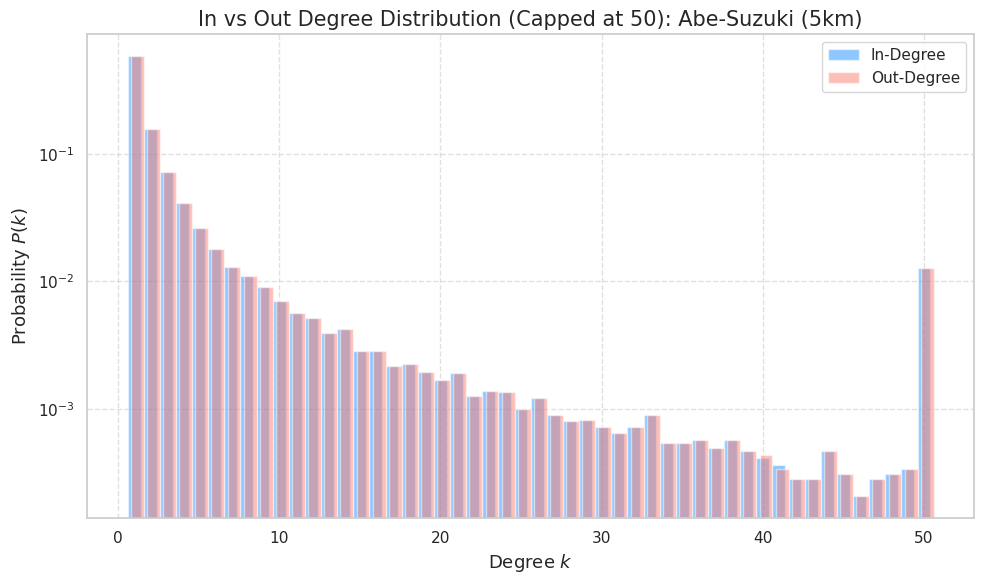

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

def plot_degree_distribution_linear(G, title, max_degree):
    """
    Plots In-Degree and Out-Degree distributions (linear scale) 
    capped at max_degree.
    """
    # Helper to calculate P(k)
    def get_prob_dist(degrees, max_k):
        # Filtriamo e applichiamo il cap
        degrees = np.array([d for d in degrees if d > 0])
        degrees = np.clip(degrees, 0, max_k)
        
        counts = pd.Series(degrees).value_counts().sort_index()
        k = counts.index.values
        P_k = counts.values / len(degrees)
        return k, P_k

    k_in, P_in = get_prob_dist([d for n, d in G.in_degree(weight='weight')], max_degree)
    k_out, P_out = get_prob_dist([d for n, d in G.out_degree(weight='weight')], max_degree)

    plt.figure(figsize=(10, 6))
    
    # Plot In-degree (Blu)
    plt.bar(k_in, P_in, color='dodgerblue', alpha=0.5, label='In-Degree', width=0.8)
    
    # Plot Out-degree (Rosso/Salmone)
    # Usiamo un offset leggero (0.2) per non sovrapporre le barre se sono contigue
    plt.bar(k_out + 0.2, P_out, color='salmon', alpha=0.5, label='Out-Degree', width=0.8)

    plt.title(f'In vs Out Degree Distribution (Capped at {max_degree}): {title}', fontsize=15)
    plt.xlabel('Degree $k$', fontsize=13)
    plt.ylabel('Probability $P(k)$', fontsize=13)
    plt.yscale('log')
    plt.legend(fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Esempio di esecuzione con cap a 20
plot_degree_distribution_linear(G_5km, "Abe-Suzuki (5km)", max_degree=50)

<>:34: SyntaxWarning: invalid escape sequence '\g'
<>:39: SyntaxWarning: invalid escape sequence '\g'
<>:34: SyntaxWarning: invalid escape sequence '\g'
<>:39: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_8145/2869065587.py:34: SyntaxWarning: invalid escape sequence '\g'
  plt.plot(k_f_in, line_in, color='blue', linestyle='--', label=f'In-Degree Fit ($\gamma={g_in:.2f}$)')
/tmp/ipykernel_8145/2869065587.py:39: SyntaxWarning: invalid escape sequence '\g'
  plt.plot(k_f_out, line_out, color='red', linestyle='--', label=f'Out-Degree Fit ($\gamma={g_out:.2f}$)')


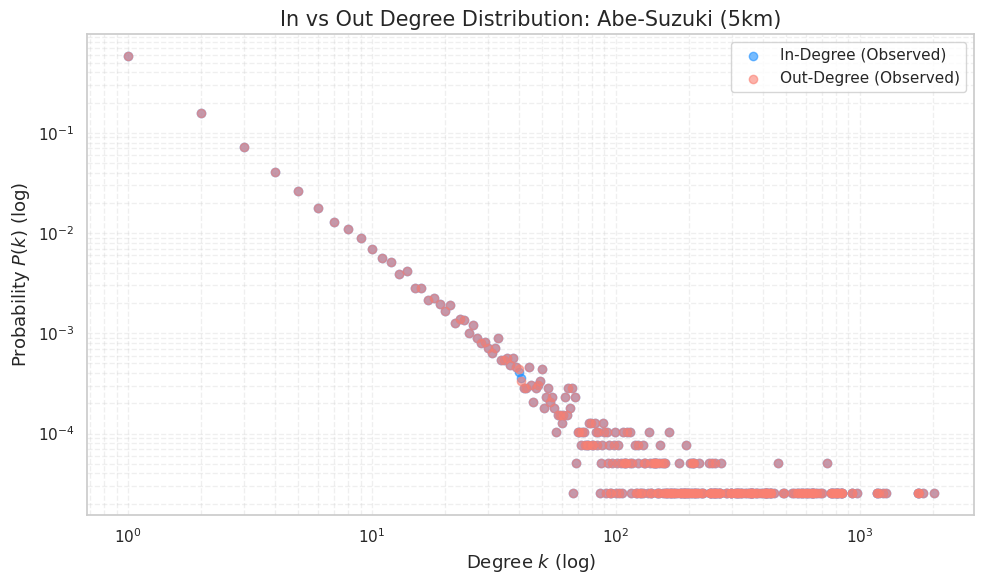

[Abe-Suzuki (5km)] Analisi completata senza fit.


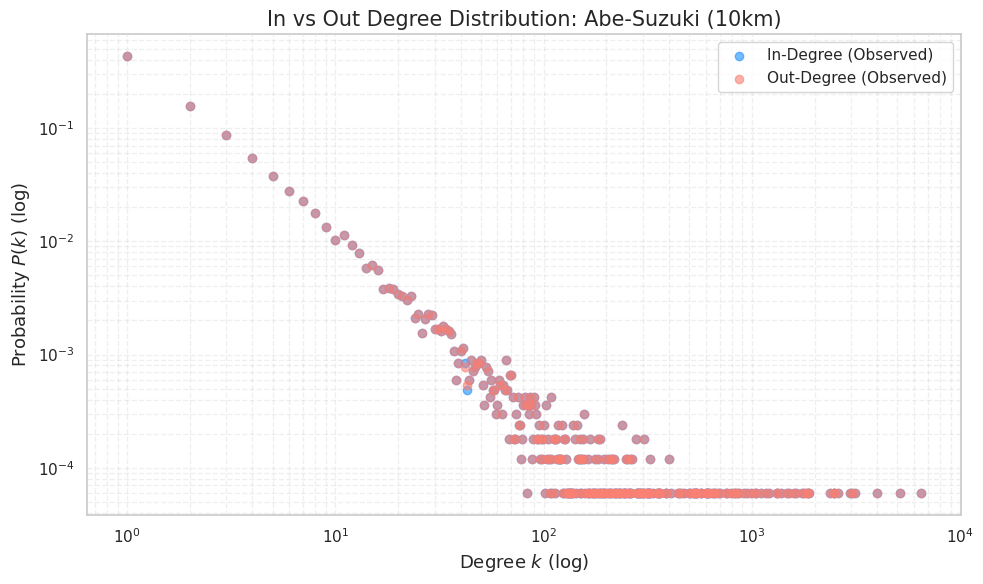

[Abe-Suzuki (10km)] Analisi completata senza fit.


In [29]:
sns.set_theme(style="whitegrid")

def analyze_in_out_degree_distribution(G, title, fit=False):
    """
    Calcola e plotta In-Degree e Out-Degree. 
    Il parametro 'fit' abilita/disabilita la regressione power-law.
    """
    
    # Helper per estrarre dati e calcolare fit opzionale
    def get_data(degrees, perform_fit):
        degrees = [d for d in degrees if d > 0]
        counts = pd.Series(degrees).value_counts().sort_index()
        k = counts.index.values
        P_k = counts.values / len(degrees)
        
        if perform_fit:
            valid_idx = k >= 2
            log_k, log_P = np.log10(k[valid_idx]), np.log10(P_k[valid_idx])
            slope, intercept, _, _, _ = linregress(log_k, log_P)
            gamma = -slope
            fit_line = 10**(intercept) * (k[valid_idx]**(-gamma))
            return k, P_k, True, k[valid_idx], fit_line, gamma
        return k, P_k, False, None, None, None

    # Estrazione pesata (Strength)
    k_in, P_in, fit_in, k_f_in, line_in, g_in = get_data([d for n, d in G.in_degree(weight='weight')], fit)
    k_out, P_out, fit_out, k_f_out, line_out, g_out = get_data([d for n, d in G.out_degree(weight='weight')], fit)

    plt.figure(figsize=(10, 6))
    
    # Plot In-degree
    plt.scatter(k_in, P_in, color='dodgerblue', alpha=0.6, label='In-Degree (Observed)')
    if fit_in:
        plt.plot(k_f_in, line_in, color='blue', linestyle='--', label=f'In-Degree Fit ($\gamma={g_in:.2f}$)')
    
    # Plot Out-degree
    plt.scatter(k_out, P_out, color='salmon', alpha=0.6, label='Out-Degree (Observed)')
    if fit_out:
        plt.plot(k_f_out, line_out, color='red', linestyle='--', label=f'Out-Degree Fit ($\gamma={g_out:.2f}$)')

    plt.xscale('log')
    plt.yscale('log')
    plt.title(f'In vs Out Degree Distribution: {title}', fontsize=15)
    plt.xlabel('Degree $k$ (log)', fontsize=13)
    plt.ylabel('Probability $P(k)$ (log)', fontsize=13)
    plt.legend(fontsize=11)
    plt.grid(True, which="both", ls="--", alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    if fit:
        print(f"[{title}] Fit completato: In-Gamma={g_in:.3f}, Out-Gamma={g_out:.3f}")
    else:
        print(f"[{title}] Analisi completata senza fit.")

# Esempio di utilizzo:
analyze_in_out_degree_distribution(G_5km, "Abe-Suzuki (5km)", fit=False)
analyze_in_out_degree_distribution(G_10km, "Abe-Suzuki (10km)", fit=False)

### IN-OUT DEGREE CHECK

In [12]:
def verify_balanced_degrees(G):
    """
    Checks if in-degree == out-degree for every node in the graph (as should be for our Network)
    Returns True if balanced, otherwise returns a list of unbalanced nodes.
    """
    unbalanced_nodes = []
    
    for node in G.nodes():
        if G.in_degree(node, weight='weight') != G.out_degree(node, weight='weight'):
            unbalanced_nodes.append(node)
            
    if not unbalanced_nodes:
        print("Success: The network is perfectly balanced (In-degree == Out-degree for all nodes).")
        return True
    else:
        print(f"Warning: Found {len(unbalanced_nodes)} unbalanced nodes.")
        return unbalanced_nodes

is_balanced = verify_balanced_degrees(G_5km)

As expected, we found exactly two nodes where in and out degree are different, and they are the first and last node of the database!

### LOG-LOG PLOT with LINEAR BINNING (not good results)

Analyzing 5km Resolution Network...
[Abe-Suzuki Network (5x5x5 km)]


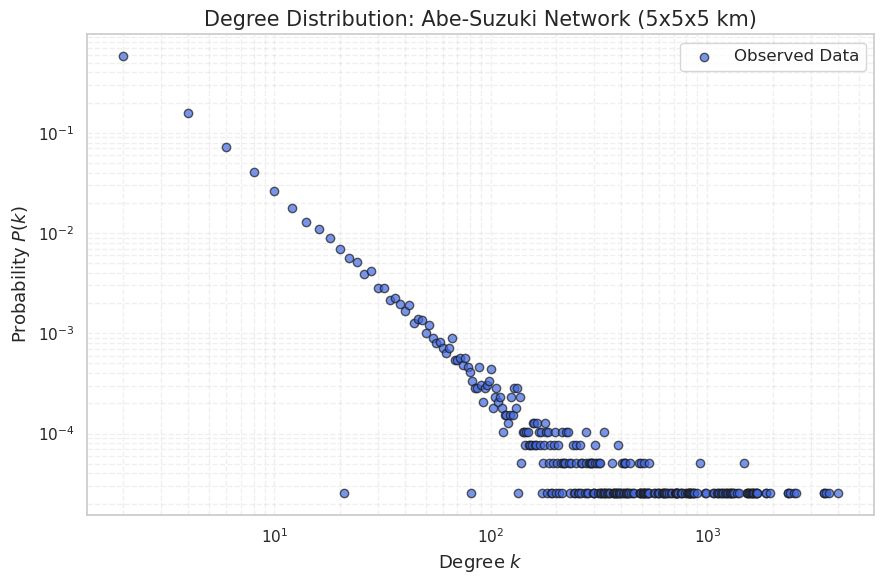


Analyzing 10km Resolution Network...
[Abe-Suzuki Network (10x10x10 km)]


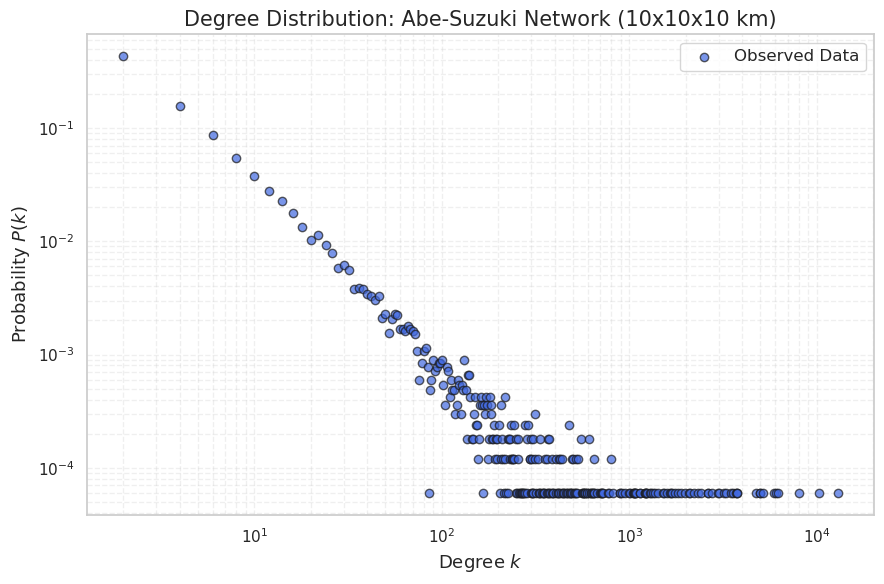

In [27]:
sns.set_theme(style="whitegrid")

# Degree Distribution Analysis Function
def analyze_degree_distribution(G, title, fit=False):
    """
    Extracts the degree of each node, calculates the probability distribution P(k),
    and fits a power-law to verify the scale-free property.
    """
    # ignore isolated nodes (degree 0) if any somehow exist
    degrees = [d for n, d in G.degree(weight='weight') if d > 0]
    
    # frequencies and probabilities
    degree_counts = pd.Series(degrees).value_counts().sort_index()
    k = degree_counts.index.values
    P_k = degree_counts.values / len(degrees)
    
    # Log-Log Linear Regression (Power-Law Fit)
    valid_idx = k >= 2
    log_k = np.log10(k[valid_idx])
    log_P = np.log10(P_k[valid_idx])

    plt.figure(figsize=(9, 6))
    plt.scatter(k, P_k, color='royalblue', alpha=0.7, edgecolors='k', label='Observed Data')    
    plt.xscale('log')
    plt.yscale('log')
    plt.title(f'Degree Distribution: {title}', fontsize=15)
    plt.xlabel('Degree $k$', fontsize=13)
    plt.ylabel('Probability $P(k)$', fontsize=13)
    plt.legend(fontsize=12)
    plt.grid(True, which="both", ls="--", alpha=0.3)

    
    # FIT ------------------------------
    if fit==True:
        slope, intercept, r_value, _, _ = linregress(log_k, log_P)
        # In a log-log plot of a power law, the slope is -gamma
        gamma = -slope
        fit_line = 10**(intercept) * (k[valid_idx]**(-gamma))
        plt.plot(k[valid_idx], fit_line, color='crimson', linewidth=2, linestyle='--',
                 label=fr'Power-law fit ($\gamma \approx {gamma:.2f}$)') 
        print(f"[{title}] Power-law exponent gamma: {gamma:.3f} (R-squared: {r_value**2:.3f})")
    else: 
        print(f"[{title}]")
    # --------------------------------
    
    plt.tight_layout()
    plt.show()

print("Analyzing 5km Resolution Network...")
analyze_degree_distribution(G_5km, "Abe-Suzuki Network (5x5x5 km)", fit=False)

print("\nAnalyzing 10km Resolution Network...")
analyze_degree_distribution(G_10km, "Abe-Suzuki Network (10x10x10 km)", fit=False)

#### degree distribution with LOG-BINNING

Analyzing 5km Resolution Network with Log-Binning...


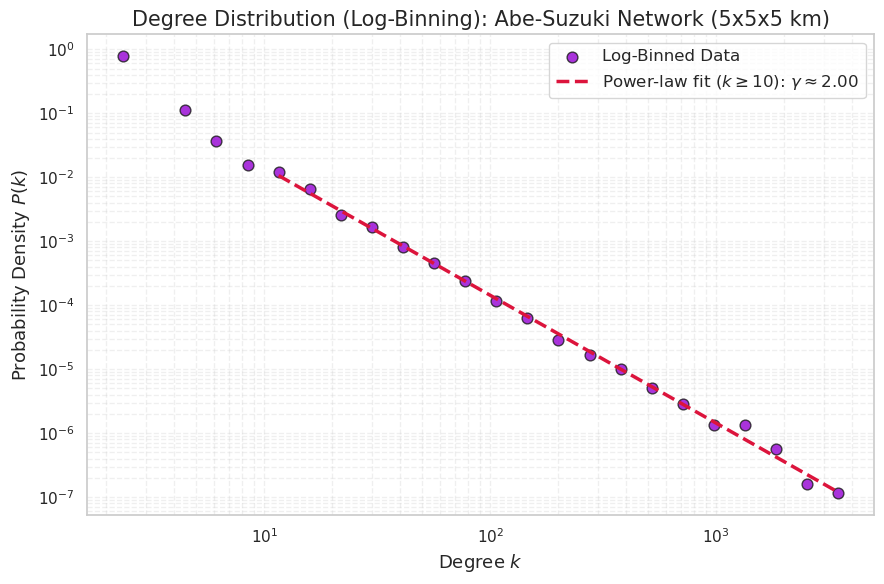

[Abe-Suzuki Network (5x5x5 km)] Power-law exponent gamma: 1.997 (R-squared: 0.997)

Analyzing 10km Resolution Network with Log-Binning...


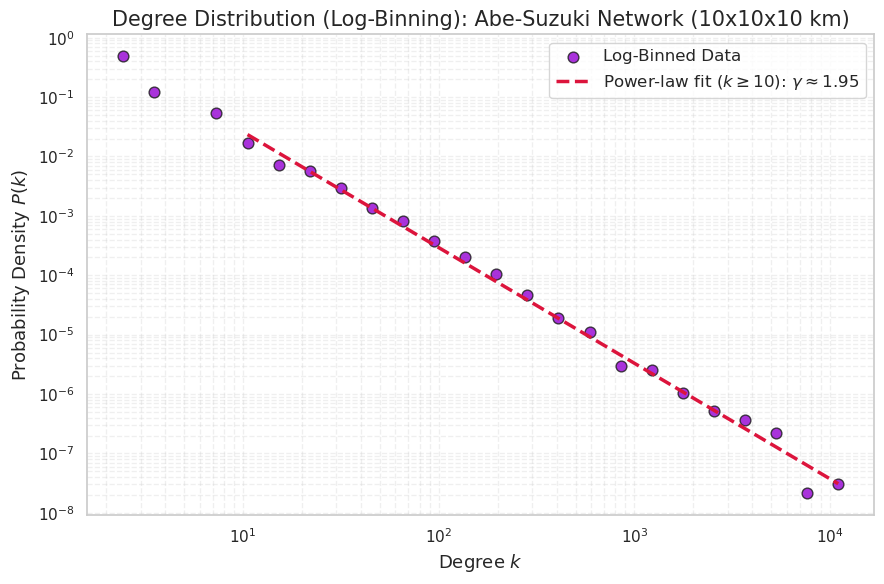

[Abe-Suzuki Network (10x10x10 km)] Power-law exponent gamma: 1.948 (R-squared: 0.993)


In [14]:
sns.set_theme(style="whitegrid")

# Log-Binning
def analyze_degree_distribution_log_binning(G, title, k_min_fit=10):
    """
    Analyzes the degree distribution using Logarithmic Binning, 
    which is the standard scientific approach for scale-free networks 
    to handle the heavy-tail noise.
    """
    degrees = [d for n, d in G.degree(weight='weight') if d > 0]
    
    if not degrees:
        print("Graph has no edges.")
        return
        
    k_min = min(degrees)
    k_max = max(degrees)
    
    # Create Logarithmic Bins
    num_bins = 25
    bins = np.logspace(np.log10(k_min), np.log10(k_max), num_bins)
    
    # Histogram
    counts, bin_edges = np.histogram(degrees, bins=bins)
    
    # bin centers and bin widths
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_widths = np.diff(bin_edges)
    
    # Normalize to Probability Density P(k)
    # divide by the width of the bin
    P_k = counts / (len(degrees) * bin_widths)
    
    # Filter empty bins
    valid_mask = P_k > 0
    k_valid = bin_centers[valid_mask]
    P_k_valid = P_k[valid_mask]
    
    # Fit the Power-Law only on the valid structural tail (k >= k_min_fit)
    fit_mask = k_valid >= k_min_fit
    
    if sum(fit_mask) > 2:
        log_k = np.log10(k_valid[fit_mask])
        log_P = np.log10(P_k_valid[fit_mask])
        
        slope, intercept, r_value, _, _ = linregress(log_k, log_P)
        gamma = -slope
        
        # Generate points for the fit line
        fit_line = 10**(intercept) * (k_valid[fit_mask]**(-gamma))
    else:
        gamma, r_value, fit_line = 0, 0, []

    plt.figure(figsize=(9, 6))
    plt.scatter(k_valid, P_k_valid, color='darkviolet', alpha=0.8, 
                edgecolors='k', s=60, label='Log-Binned Data')
    if sum(fit_mask) > 2:
        plt.plot(k_valid[fit_mask], fit_line, color='crimson', linewidth=2.5, 
                 linestyle='--', label=fr'Power-law fit ($k \geq {k_min_fit}$): $\gamma \approx {gamma:.2f}$')
    
    plt.xscale('log')
    plt.yscale('log')
    plt.title(f'Degree Distribution (Log-Binning): {title}', fontsize=15)
    plt.xlabel('Degree $k$', fontsize=13)
    plt.ylabel('Probability Density $P(k)$', fontsize=13)
    plt.legend(fontsize=12)
    plt.grid(True, which="both", ls="--", alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"[{title}] Power-law exponent gamma: {gamma:.3f} (R-squared: {r_value**2:.3f})")

print("Analyzing 5km Resolution Network with Log-Binning...")
analyze_degree_distribution_log_binning(G_5km, "Abe-Suzuki Network (5x5x5 km)", k_min_fit=10)

print("\nAnalyzing 10km Resolution Network with Log-Binning...")
analyze_degree_distribution_log_binning(G_10km, "Abe-Suzuki Network (10x10x10 km)", k_min_fit=10)

### using CCDF

In [15]:
def plot_ccdf_with_fit(G, title, k_min_fit=10):
    degrees = np.array([d for _, d in G.degree(weight='weight') if d > 0])
    
    if len(degrees) == 0:
        print("Empty graph")
        return
    
    # Sort degrees
    k_vals = np.sort(np.unique(degrees))
    
    # CCDF: P(K >= k)
    ccdf = np.array([np.mean(degrees >= k) for k in k_vals])
    
    # Fit only tail
    mask = k_vals >= k_min_fit
    
    if np.sum(mask) > 2:
        log_k = np.log10(k_vals[mask])
        log_p = np.log10(ccdf[mask])
        
        slope, intercept, r, _, _ = linregress(log_k, log_p)
        gamma = 1 - slope
        
        fit_line = 10**intercept * k_vals[mask]**slope
    else:
        gamma, r, fit_line = np.nan, 0, None
    
    # Plot
    plt.figure(figsize=(8,6))
    
    plt.scatter(k_vals, ccdf, s=40, label="CCDF", alpha=0.8)
    
    if fit_line is not None:
        plt.plot(k_vals[mask], fit_line, 'r--',
                 label=f"Fit: γ ≈ {gamma:.2f}")
    
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Degree k")
    plt.ylabel("P(K ≥ k)")
    plt.title(f"CCDF Degree Distribution: {title}")
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.3)
    plt.show()
    
    print(f"[{title}] gamma ≈ {gamma:.3f}, R² ≈ {r**2:.3f}")

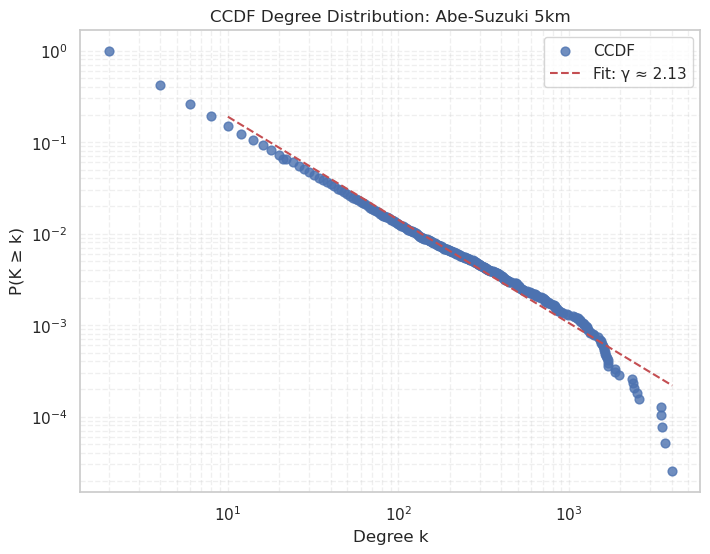

[Abe-Suzuki 5km] gamma ≈ 2.128, R² ≈ 0.965


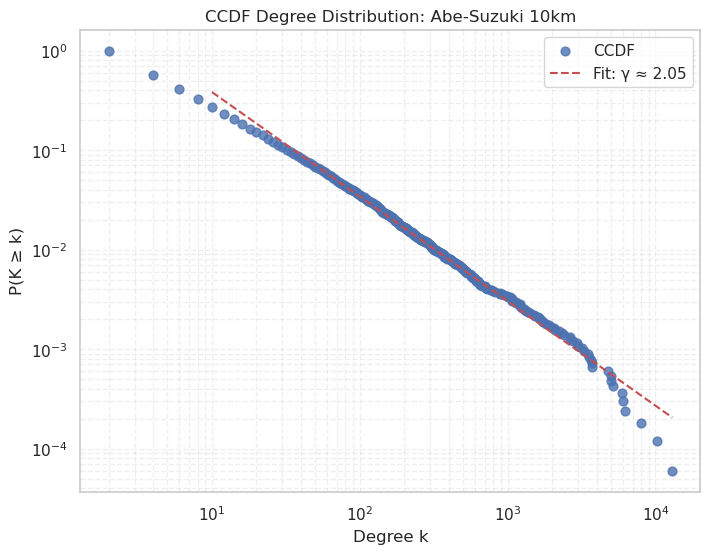

[Abe-Suzuki 10km] gamma ≈ 2.051, R² ≈ 0.991


In [16]:
plot_ccdf_with_fit(G_5km, "Abe-Suzuki 5km")
plot_ccdf_with_fit(G_10km, "Abe-Suzuki 10km")

### ESTIMATING $\gamma$ with MLE

A better way to find $\gamma$ wrt linear fit, would be to use a *Maximum Likelihood Estimate* (MLE). 

Each datum (node) has a likelihood (simply given by the probability $p_k$, with $\gamma$ given and $C$ explicitated):
$$
p(k|\gamma) = \frac{\gamma-1}{k_{\min}}  \left(\frac{k}{k_{\min}} \right)^{-\gamma}
$$

Assuming data to be independent, the total likelihood of a dataset is the *product* of the likelihood of each node. Then we compute the logarithm to reduce it to a sum, and select the $\gamma$ that maximizes the total likelihood:
$$
    \max_\gamma f(\gamma) = \max_\gamma \sum_i \ln p(k_i|\gamma) \qquad 
    f(\gamma) = \sum_i \Big[ \ln \frac{\gamma-1}{k_{\min}} - \gamma \ln \frac{k_i}{k_{\min}}  \Big]
$$
This can be found by setting the first derivative to $0$:
$$
    f'(\gamma) = 
    \sum_i \Big[ \frac{1}{\gamma-1} - \ln \frac{k_i}{k_{\min}} \Big] 
    \overset{!}{=} 0
$$
And we find:
$$
    \gamma = 1 + \sum_i \frac{1}{\sum_i \ln (k_i/k_{\min})} = 1 + n \left[ \sum_i \ln \frac{k_i}{k_{\min}} \right]^{-1}
$$

In [17]:
def estimate_gamma_mle(degrees, k_min):
    
    degrees = np.array(degrees)
    tail = degrees[degrees >= k_min]   # keep only tail
    n = len(tail)
    
    if n < 2:
        return np.nan
    
    gamma = 1 + n / np.sum(np.log(tail / k_min))
    return gamma

In [20]:
degrees = [d for _, d in G_5km.degree(weight='weight') if d > 0]

gamma_mle = estimate_gamma_mle(degrees, k_min=10)
print(f"MLE gamma for 5km network:  {gamma_mle:.2f}")

degrees = [d for _, d in G_10km.degree(weight='weight') if d > 0]

gamma_mle = estimate_gamma_mle(degrees, k_min=10)
print(f"MLE gamma for 10km network: {gamma_mle:.2f}")

MLE gamma for 5km network:  2.11
MLE gamma for 10km network: 1.92


Things from the paper to be verified:
* Since the number of vertices with large degrees of connectivity decreases if the cell size becomes smaller, the value of $\gamma$ should be larger for smaller cells, in general.
* The value of $\gamma$ becomes larger if small earthquakes are eliminated. This is natural, since small aftershocks tend to connect with mainshocks (i.e., hubs).
* The value of the exponent, $\gamma$, is ascertained to remain constant in time according to the evolution of the earthquake network. The fact that $\gamma$ remains constant in time indicates that this exponent may be characteristic for the plate under investigation.

---

---

# (READ UNTIL HERE)

---

---

## Mapping the top 2% Hubs

In [4]:
import pandas as pd
import plotly.express as px
import plotly.io as pio
import networkx as nx

pio.renderers.default = 'iframe' 

# Extract degrees and coordinates from Network
node_data = []
for node in G_10km.nodes():
    # Only keep nodes that have coordinates
    if 'lat' in G_10km.nodes[node] and 'lon' in G_10km.nodes[node]:
        node_data.append({
            'cell_id': node,
            'degree': G_10km.degree(node),
            'lat': G_10km.nodes[node]['lat'],
            'lon': G_10km.nodes[node]['lon']
        })

df_nodes = pd.DataFrame(node_data)
df_nodes = df_nodes[df_nodes['degree'] > 0]

# Identify the hubs
threshold = df_nodes['degree'].quantile(0.98)
df_hubs = df_nodes[df_nodes['degree'] >= threshold].copy()

print(f"Total active cells: {len(df_nodes)}")
print(f"Mapping the top {len(df_hubs)} Hubs (Degree >= {threshold:.0f})...")

fig = px.scatter_mapbox(
    df_hubs, 
    lat="lat", 
    lon="lon", 
    color="degree",
    size="degree",
    color_continuous_scale="inferno",
    zoom=4.5,
    center={"lat": 41.9, "lon": 12.5},
    mapbox_style="carto-positron",
    hover_name="cell_id",
    hover_data={"lat": ":.3f", "lon": ":.3f", "degree": True},
    title="Abe-Suzuki Network Hubs: Top 2% Most Active Seismic Cells (10x10x10 km)"
)

fig.update_layout(margin={"r": 0, "t": 40, "l": 0, "b": 0})
fig.show()

Total active cells: 16679
Mapping the top 337 Hubs (Degree >= 129)...


/tmp/ipykernel_1694197/2907142154.py:30: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


## Generating upgraded 3D Network Hub Map with Italy surface map

In [5]:
import plotly.graph_objects as go
import plotly.express as px
import geopandas as gpd
import pandas as pd

# download from https://www.naturalearthdata.com/

print("Download Italy's geometry to draw the surface map...")

# Set Italy Boundaries
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
italy_geom = world[world['ADMIN'] == "Italy"].geometry.iloc[0]

geometries = [italy_geom] if italy_geom.geom_type == 'Polygon' else italy_geom.geoms
df_hubs['depth_km'] = df_hubs['cell_id'].apply(lambda x: float(x.split('_')[2]) * 10)
lons_map, lats_map, zs_map = [], [], []
for polygon in geometries:
    x, y = polygon.exterior.coords.xy
    lons_map.extend(x)
    lats_map.extend(y)
    zs_map.extend([0] * len(x)) # map at surface level
    
    lons_map.append(None)
    lats_map.append(None)
    zs_map.append(None)

fig_3d = px.scatter_3d(
    df_hubs, 
    x='lon', y='lat', z='depth_km',
    color='degree', size='degree',
    color_continuous_scale='inferno',
    hover_name='cell_id',
    hover_data={'lat': ':.2f', 'lon': ':.2f', 'depth_km': True, 'degree': True}
)

fig_3d.add_trace(go.Scatter3d(
    x=lons_map, y=lats_map, z=zs_map,
    mode='lines',
    line=dict(color='blue', width=3),
    name='Italy Surface (0 km)',
    hoverinfo='skip'
))

fig_3d.update_layout(
    template="plotly_white",
    scene=dict(
        zaxis=dict(autorange="reversed", title="Depth (km)"),
        xaxis=dict(title="Longitude"),
        yaxis=dict(title="Latitude"),
        aspectratio=dict(x=1, y=1.5, z=0.6) 
    ),
    margin=dict(l=0, r=0, b=0, t=40),
    title="3D View of Seismic Hubs with Surface Coastline"
)

# remove points border
fig_3d.update_traces(marker=dict(line=dict(width=0)))
fig_3d.show()

Download Italy's geometry to draw the surface map...


# Macroscopic Network Analysis

## Calculating some metrics
- Giant Component Analysis
- Clustering coefficients
- Diameter and Path average length
- Adjacency Matrix

  MACROSCOPIC SEISMIC NETWORK ANALYSIS   
--- Giant Component Analysis ---
Total isolated components: 1
Giant Component Size: 16679 nodes (100.00% of the whole network)
--- Clustering Coefficient ---
Average Clustering Coefficient (C): 0.1499
Expected C for a Random Graph:    0.0009
--- Diameter & Average Path Length ---
Calculating shortest paths...
Average Path Length (L): 3.31 steps
Network Diameter:        8 steps
Calculation time:        1517.5 seconds
--- Adjacency Matrix ---
Matrix Shape: (16679, 16679)
Non-Zero elements (Edges): 130999
Matrix Sparsity: 99.9529%


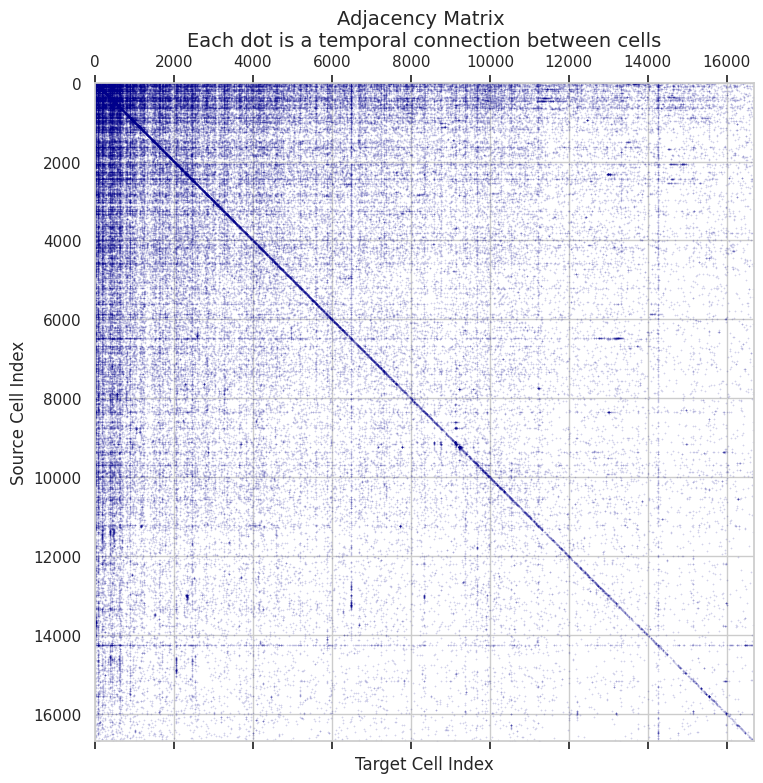

In [6]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import time
import scipy.sparse as sp

G = G_10km

print("  MACROSCOPIC SEISMIC NETWORK ANALYSIS   ")
print("--- Giant Component Analysis ---")
# In directed graphs, we use Weakly Connected Components
# to find the overall physical structure.
wcc = list(nx.weakly_connected_components(G))
largest_wcc_nodes = max(wcc, key=len)
G_giant = G.subgraph(largest_wcc_nodes).copy()

total_nodes = G.number_of_nodes()
giant_nodes = G_giant.number_of_nodes()
percentage = (giant_nodes / total_nodes) * 100

print(f"Total isolated components: {len(wcc)}")
print(f"Giant Component Size: {giant_nodes} nodes ({percentage:.2f}% of the whole network)")
# Clustering Coefficient (triangles)
print("--- Clustering Coefficient ---")
G_undirected = G_giant.to_undirected()

# Remove self-loops for clustering calculation
G_undirected.remove_edges_from(nx.selfloop_edges(G_undirected))

start_time = time.time()
avg_clustering = nx.average_clustering(G_undirected)
print(f"Average Clustering Coefficient (C): {avg_clustering:.4f}")

# clustering of a random graph with the same nodes and edges for comparison
p_random = (2 * G_undirected.number_of_edges()) / (giant_nodes * (giant_nodes - 1))
print(f"Expected C for a Random Graph:    {p_random:.4f}")

#  Path Length and Diameter
print("--- Diameter & Average Path Length ---")
print("Calculating shortest paths...")

start_time = time.time()
avg_path_length = nx.average_shortest_path_length(G_undirected)
diameter = nx.diameter(G_undirected)
calc_time = time.time() - start_time

print(f"Average Path Length (L): {avg_path_length:.2f} steps")
print(f"Network Diameter:        {diameter} steps")
print(f"Calculation time:        {calc_time:.1f} seconds")

# Adjacency Matrix n Sparsity
print("--- Adjacency Matrix ---")
#  scipy sparse matrix for memory efficiency
adj_matrix = nx.to_scipy_sparse_array(G)
sparsity = 1.0 - (adj_matrix.nnz / (total_nodes ** 2))

print(f"Matrix Shape: {adj_matrix.shape}")
print(f"Non-Zero elements (Edges): {adj_matrix.nnz}")
print(f"Matrix Sparsity: {sparsity * 100:.4f}%")

plt.figure(figsize=(8, 8))
plt.spy(adj_matrix, markersize=0.05, color='darkblue')
plt.title("Adjacency Matrix \nEach dot is a temporal connection between cells", fontsize=14)
plt.xlabel("Target Cell Index", fontsize=12)
plt.ylabel("Source Cell Index", fontsize=12)
plt.tight_layout()
plt.show()

## CALCULATING GLOBAL CENTRALITY METRICS  
- Degree Centrality
- PageRank
- Closeness Centrality
- Betweenness Centrality (K=1000)


In [7]:
import pandas as pd
import networkx as nx
import time

print("  CALCULATING GLOBAL CENTRALITY METRICS  ")
start_time = time.time()

# Degree Centrality
print("Computing Degree Centrality...")
deg_cent = nx.degree_centrality(G_10km)

# PageRank Centrality
print("Computing PageRank Centrality...")
pagerank_cent = nx.pagerank(G_10km, weight='weight')

# Closeness Centrality
print("Computing Closeness Centrality...")
close_cent = nx.closeness_centrality(G_10km)

# Betweenness Centrality
print("Computing Betweenness Centrality...")
bet_cent = nx.betweenness_centrality(G_10km, k=1000, seed=42)

calc_time = time.time() - start_time
print(f"\nAll metrics calculated in {calc_time:.1f} seconds!")

# Build the DataFrame
metrics_data = []
for node in G_10km.nodes():
    if 'lat' in G_10km.nodes[node] and 'lon' in G_10km.nodes[node]:
        metrics_data.append({
            'cell_id': node,
            'lat': G_10km.nodes[node]['lat'],
            'lon': G_10km.nodes[node]['lon'],
            'depth_km': float(node.split('_')[2]) * 10,  # Recover depth from ID
            'Degree': deg_cent[node],
            'Betweenness': bet_cent[node],
            'Closeness': close_cent[node],
            'PageRank': pagerank_cent[node]
        })

df_centrality = pd.DataFrame(metrics_data)

# Top 5 Cells for Each Metric
def display_top_5(df, metric, title):
    print(f"\n--- Top 5 Cells: {title} ---")
    top_5 = df.sort_values(metric, ascending=False).head(5)
    # Format the output
    display(top_5[['cell_id', 'lat', 'lon', 'depth_km', metric]].style.format({
        'lat': "{:.3f}", 'lon': "{:.3f}", 'depth_km': "{:.1f}", metric: "{:.6f}"
    }))

display_top_5(df_centrality, 'Degree', 'Most Active Swarms (Degree)')
display_top_5(df_centrality, 'Betweenness', 'Structural Bridges (Betweenness)')
display_top_5(df_centrality, 'Closeness', 'Topological Centers (Closeness)')
display_top_5(df_centrality, 'PageRank', 'Stress Sinks (PageRank)')

  CALCULATING GLOBAL CENTRALITY METRICS  
Computing Degree Centrality...
Computing PageRank Centrality...
Computing Closeness Centrality...
Computing Betweenness Centrality...

All metrics calculated in 562.5 seconds!

--- Top 5 Cells: Most Active Swarms (Degree) ---


,cell_id,lat,lon,depth_km,Degree
28,80_104_0,43.409,12.494,0.0,0.099352
2061,85_100_0,43.031,13.067,0.0,0.090239
375,86_97_1,42.765,13.178,10.0,0.085862
65,87_94_1,42.489,13.291,10.0,0.085562
2448,87_95_1,42.579,13.279,10.0,0.085082



--- Top 5 Cells: Structural Bridges (Betweenness) ---


,cell_id,lat,lon,depth_km,Betweenness
28,80_104_0,43.409,12.494,0.0,0.056608
2061,85_100_0,43.031,13.067,0.0,0.047593
65,87_94_1,42.489,13.291,10.0,0.044114
2448,87_95_1,42.579,13.279,10.0,0.042949
375,86_97_1,42.765,13.178,10.0,0.042279



--- Top 5 Cells: Topological Centers (Closeness) ---


,cell_id,lat,lon,depth_km,Closeness
28,80_104_0,43.409,12.494,0.0,0.419245
2448,87_95_1,42.579,13.279,10.0,0.415589
65,87_94_1,42.489,13.291,10.0,0.414298
375,86_97_1,42.765,13.178,10.0,0.412169
2061,85_100_0,43.031,13.067,0.0,0.410293



--- Top 5 Cells: Stress Sinks (PageRank) ---


,cell_id,lat,lon,depth_km,PageRank
2061,85_100_0,43.031,13.067,0.0,0.016003
375,86_97_1,42.765,13.178,10.0,0.015494
2448,87_95_1,42.579,13.279,10.0,0.012038
614,86_98_1,42.840,13.180,10.0,0.008781
65,87_94_1,42.489,13.291,10.0,0.008323


## Community Detection algorithm

### Louvain Algorithm

In [8]:
import networkx as nx
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import geopandas as gpd

print("  COMMUNITY DETECTION (LOUVAIN METHOD)   ")
# Louvain works best on undirected graphs so we get the giant Component.
G_undirected = G_giant.to_undirected()

# Remove self-loops 
G_undirected.remove_edges_from(nx.selfloop_edges(G_undirected))

print("Running Louvain algorithm...")
communities = nx.community.louvain_communities(G_undirected, seed=42)

print(f"Algorithm discovered {len(communities)} distinct seismic communities.\n")

# community IDs to the nodes
community_mapping = {}
for comm_id, node_set in enumerate(communities):
    for node in node_set:
        community_mapping[node] = comm_id

# data for visualization
comm_data = []
for node in G_undirected.nodes():
    if 'lat' in G_undirected.nodes[node] and 'lon' in G_undirected.nodes[node]:
        comm_data.append({
            'cell_id': node,
            'community': str(community_mapping[node]), 
            'lat': G_undirected.nodes[node]['lat'],
            'lon': G_undirected.nodes[node]['lon'],
            'degree': G_undirected.degree(node)
        })

df_comm = pd.DataFrame(comm_data)

# Filter tiny communities to make the map readable
# communities with > 50 cells
comm_counts = df_comm['community'].value_counts()
large_communities = comm_counts[comm_counts >= 50].index
df_comm_filtered = df_comm[df_comm['community'].isin(large_communities)].copy()

print(f"Mapping the {len(large_communities)} largest structural fault systems...")

# get Italy boundaries for the surface map
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
italy_geom = world[world['ADMIN'] == "Italy"].geometry.iloc[0]
geometries = [italy_geom] if italy_geom.geom_type == 'Polygon' else italy_geom.geoms

lons_map, lats_map = [], []
for polygon in geometries:
    x, y = polygon.exterior.coords.xy
    lons_map.extend(x)
    lats_map.extend(y)
    lons_map.append(None)
    lats_map.append(None)

# Plot the Communities
fig_comm = px.scatter_geo(
    df_comm_filtered, 
    lat="lat", 
    lon="lon", 
    color="community", 
    size="degree",     # hubs
    color_discrete_sequence=px.colors.qualitative.Bold,
    hover_name="community",
    hover_data={"lat": ":.3f", "lon": ":.3f", "degree": True},
    title="Earthquake communities (Louvain Method)",
    scope="europe" 
)

fig_comm.update_traces(marker=dict(sizemin=1, opacity=0.7, line=dict(width=0)))
fig_comm.update_geos(
    showsubunits=True, 
    subunitcolor="LightGray",
    showcountries=True,
    countrycolor="Black",
    lataxis_range=[34, 48],
    lonaxis_range=[3, 22]
)

fig_comm.update_layout(
    margin={"r": 0, "t": 40, "l": 0, "b": 0}, 
    showlegend=True, 
    geo=dict(bgcolor='rgba(0,0,0,0)') 
)

fig_comm.show()

  COMMUNITY DETECTION (LOUVAIN METHOD)   
Running Louvain algorithm...
Algorithm discovered 17 distinct seismic communities.

Mapping the 16 largest structural fault systems...


## SAVE Centrality Results
- CellID
- Degree
- Betweenness
- Closeness
- PageRank


In [10]:
df_final_results = pd.merge(df_centrality, df_comm[['cell_id', 'community']], on='cell_id', how='left')
df_final_results.to_csv("results/italian_eq_network_metrics.csv", index=False)
print("data successfully exported to 'italian_eq_network_metrics.csv'!")

data successfully exported to 'italian_eq_network_metrics.csv'!
